验证所有数据归一化(在剩余总额中的比例)后是否符合理论上的均匀分布

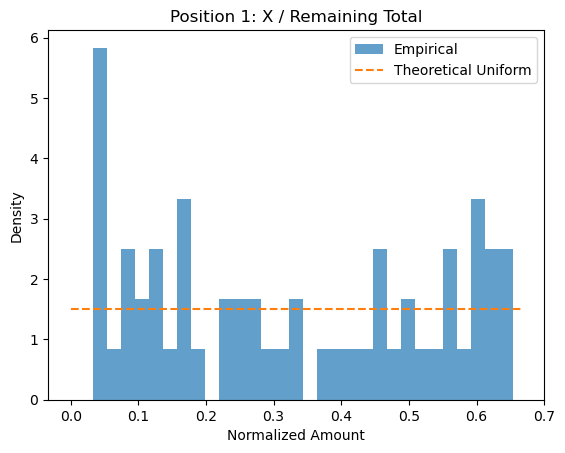

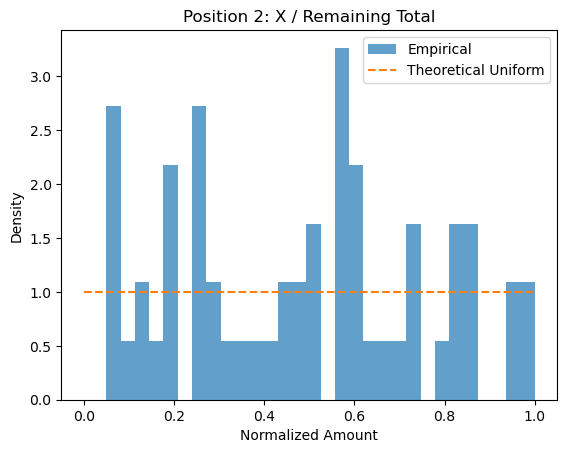

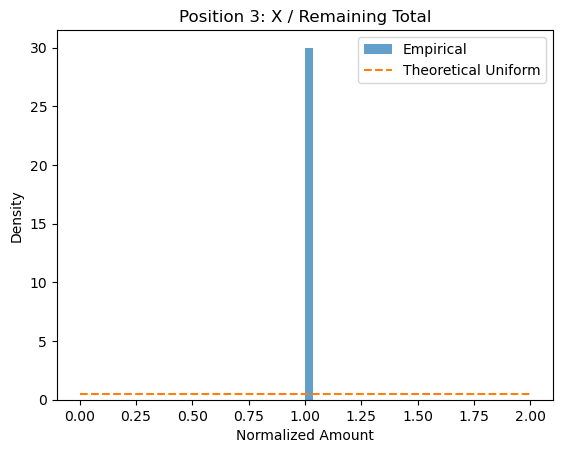

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================
# 1. 读取数据
# =====================
# 假设:
# 行 = 实验次数
# 列 = 位次 (第1个抢到的人, 第2个, ...)
df = pd.read_csv("3peoplerealdata.csv")

# Skip the 'Trial' column (first column)
df_data = df.iloc[:, 1:]

num_positions = df_data.shape[1]

# =====================
# 2. 计算归一化比例
# =====================
ratios = {}

for i, col in enumerate(df_data.columns):
    # 剩余总额（包含自己）
    remaining_sum = df_data.iloc[:, i:].sum(axis=1)
    ratios[col] = df_data[col] / remaining_sum

ratio_df = pd.DataFrame(ratios)

# =====================
# 3. 绘制直方图验证均匀分布
# =====================
for i, col in enumerate(ratio_df.columns):
    plt.figure()
    plt.hist(
        ratio_df[col],
        bins=30,
        density=True,
        alpha=0.7,
        label="Empirical"
    )

    # 理论均匀分布上界
    upper = 2 / (num_positions - i)

    x = np.linspace(0, upper, 200)
    y = np.ones_like(x) / upper
    plt.plot(x, y, linestyle="--", label="Theoretical Uniform")

    plt.title(f"Position {i+1}: X / Remaining Total")
    plt.xlabel("Normalized Amount")
    plt.ylabel("Density")
    plt.legend()
    plt.show()